# Akhilesh
## DATA 266 - Homework 1



In [11]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SID4 = 6812
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print(f"SID4={SID4}, SEED={SEED}, SLICE={SLICE}, HP_ID={HP_ID}, CLS_A={CLS_A}, CLS_B={CLS_B}")


SID4=6812, SEED=6812, SLICE=812, HP_ID=2, CLS_A=2, CLS_B=9


## 0. What are autoregressive models?

An autoregressive model generates or predicts the next value by conditioning on previous values. In language modeling, that means predicting the next token from the tokens already seen; in time-series work, it means predicting the next observation from earlier observations. The important constraint is that the model only uses past context, not future values, when making each prediction.

Real-world examples include phone keyboard autocomplete, ChatGPT-style next-token generation, weather or electricity-demand forecasting from past measurements, and speech/audio generation where each new sample or chunk depends on earlier audio. A simple non-AI example is a financial time-series model that predicts tomorrow's sales using sales from the last several days.


## 1. Load, preprocess, and visualize the data



In [12]:
DATA_PATH = Path("../diabetes.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("diabetes.csv")

columns = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "pedigree",
    "age",
    "diabetes",
]

df = pd.read_csv(DATA_PATH, header=None, names=columns)
display(df.head())
print("shape:", df.shape)
print("missing values:", int(df.isna().sum().sum()))
display(df["diabetes"].value_counts().sort_index().rename("count").to_frame())
display(df.describe().T[["mean", "std", "min", "max"]].round(3))


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,pedigree,age,diabetes
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


shape: (759, 9)
missing values: 0


,count
diabetes,
0,263
1,496


,mean,std,min,max
pregnancies,-0.408,0.386,-0.882,1.0
glucose,0.219,0.306,-0.558,1.0
blood_pressure,0.177,0.201,-0.607,1.0
skin_thickness,-0.290,0.258,-0.859,1.0
insulin,-0.324,0.376,-0.967,1.0
bmi,-0.032,0.205,-0.458,1.0
pedigree,-0.663,0.283,-0.995,1.0
age,-0.516,0.401,-0.967,1.0
diabetes,0.653,0.476,0.000,1.0


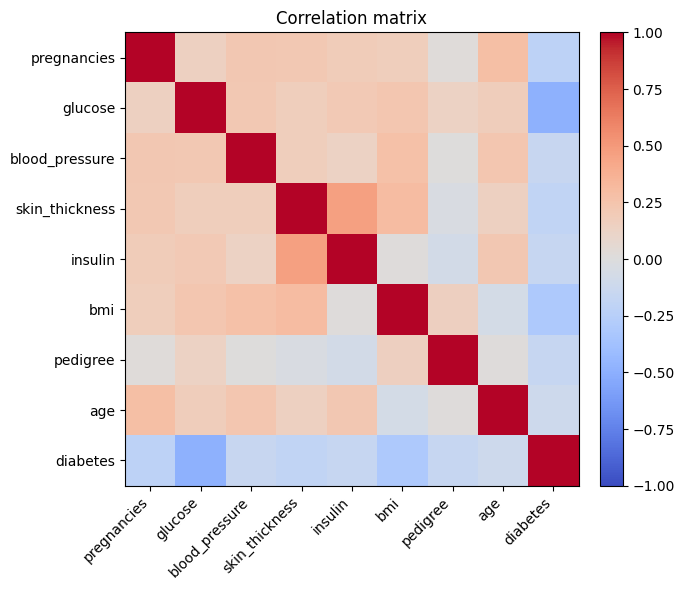

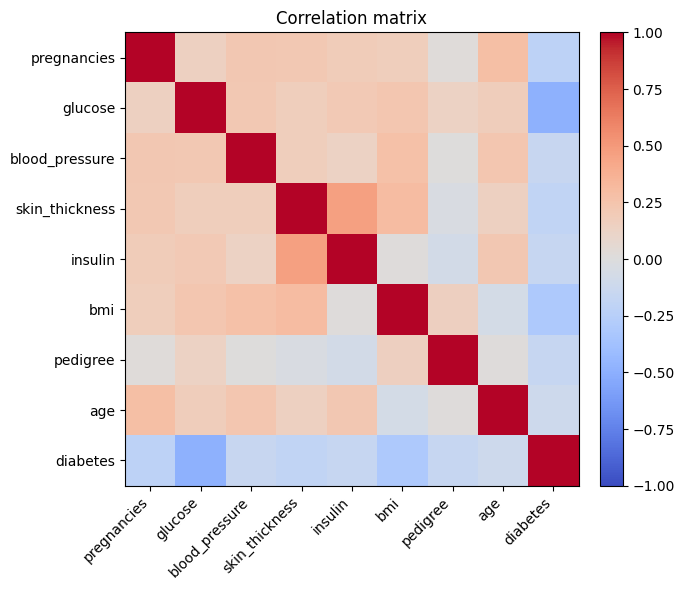

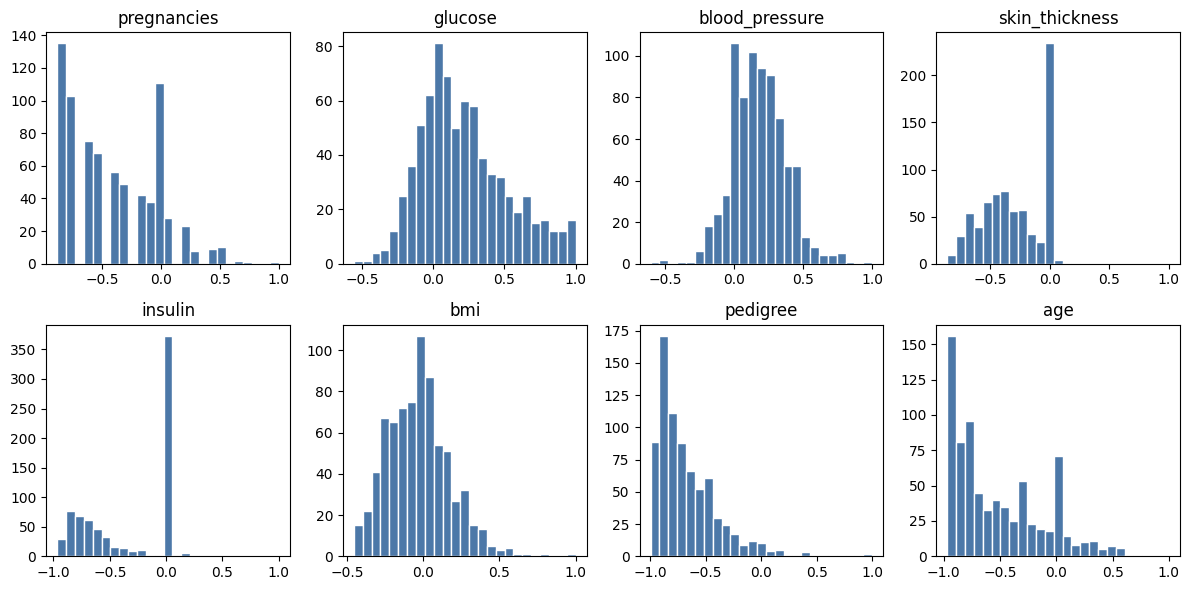

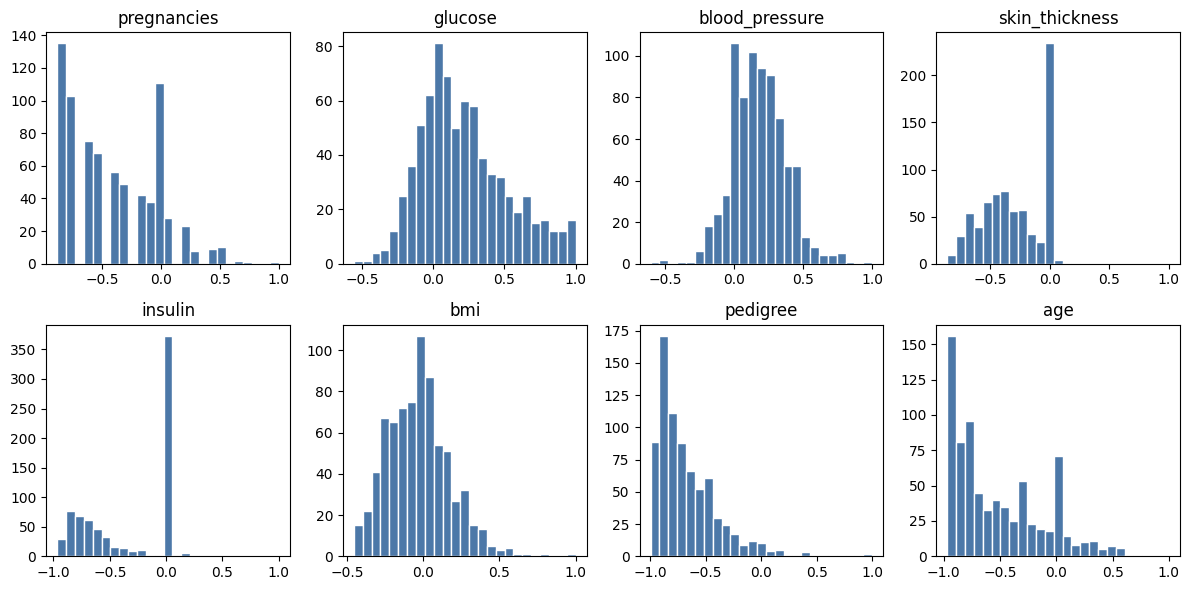

In [13]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation matrix")
plt.tight_layout()
display(fig)
plt.show()

feature_cols = columns[:-1]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, col in zip(axes.ravel(), feature_cols):
    ax.hist(df[col], bins=25, color="#4C78A8", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
display(fig)
plt.show()


In [14]:
X = df[feature_cols].to_numpy(dtype=np.float32)
y = df["diabetes"].to_numpy(dtype=np.float32)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print("train:", X_train.shape, "validation:", X_val.shape, "test:", X_test.shape)
print("test positive rate:", round(float(y_test.mean()), 3))


train: (531, 8) validation: (114, 8) test: (114, 8)
test positive rate: 0.649


## 2. PyTorch models



In [15]:
BASELINE_CONFIG = {"name": "baseline", "hidden": [64, 32], "lr": 0.001, "epochs": 30}
MODIFIED_CONFIG = {"name": "modified_HP2", "hidden": [64, 32], "lr": 0.003, "epochs": 30}
TRAINING_SEEDS = [SEED, SEED + 1, SEED + 2]


class TorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()
        layers = []
        last_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(nn.ReLU())
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_torch_model(config, training_seed, keep_history=False):
    random.seed(training_seed)
    np.random.seed(training_seed)
    torch.manual_seed(training_seed)

    model = TorchMLP(X_train.shape[1], config["hidden"])
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    loss_fn = nn.BCEWithLogitsLoss()
    generator = torch.Generator().manual_seed(training_seed)
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train).reshape(-1, 1))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=generator)

    X_val_t = torch.tensor(X_val)
    y_val_t = torch.tensor(y_val).reshape(-1, 1)
    history = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": val_loss})

    model.eval()
    with torch.no_grad():
        test_prob = torch.sigmoid(model(torch.tensor(X_test))).numpy().ravel()
    test_pred = (test_prob >= 0.5).astype(int)
    test_acc = accuracy_score(y_test, test_pred)
    return test_acc, pd.DataFrame(history)


torch_rows = []
torch_histories = {}
for config in [BASELINE_CONFIG, MODIFIED_CONFIG]:
    for training_seed in TRAINING_SEEDS:
        acc, hist = train_torch_model(config, training_seed)
        torch_rows.append({"framework": "PyTorch", "model": config["name"], "training_seed": training_seed, "test_accuracy": acc})
        if training_seed == SEED:
            torch_histories[config["name"]] = hist

torch_runs = pd.DataFrame(torch_rows)
display(torch_runs.round(4))
torch_summary = (
    torch_runs.groupby(["framework", "model"])["test_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)
display(torch_summary.round(4))


,framework,model,training_seed,test_accuracy
0,PyTorch,baseline,6812,0.7632
1,PyTorch,baseline,6813,0.7281
2,PyTorch,baseline,6814,0.7105
3,PyTorch,modified_HP2,6812,0.7719
4,PyTorch,modified_HP2,6813,0.7544
5,PyTorch,modified_HP2,6814,0.7544


,framework,model,mean,std
0,PyTorch,baseline,0.7339,0.0268
1,PyTorch,modified_HP2,0.7602,0.0101


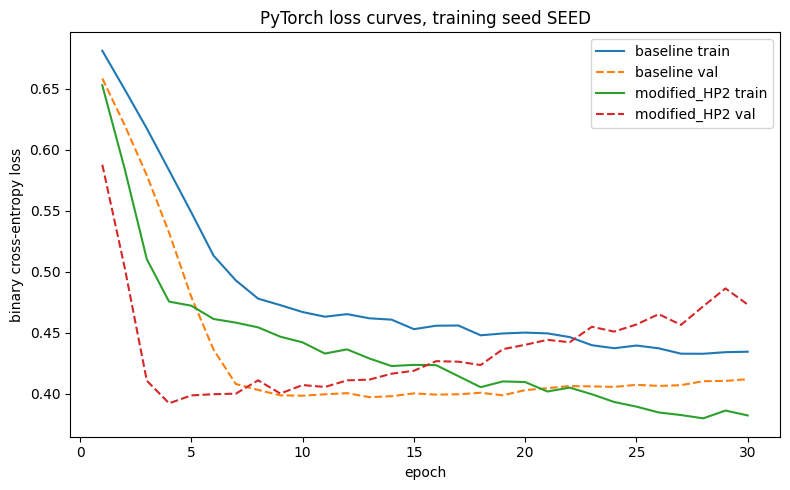

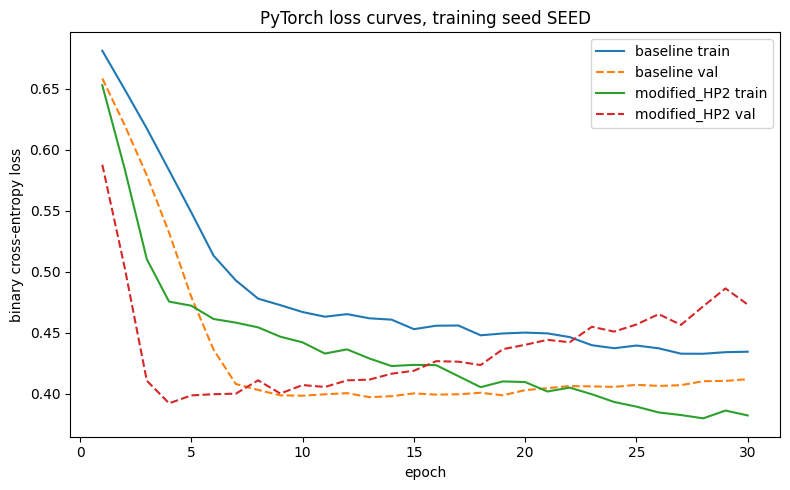

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name, hist in torch_histories.items():
    ax.plot(hist["epoch"], hist["train_loss"], label=f"{model_name} train")
    ax.plot(hist["epoch"], hist["val_loss"], linestyle="--", label=f"{model_name} val")
ax.set_title("PyTorch loss curves, training seed SEED")
ax.set_xlabel("epoch")
ax.set_ylabel("binary cross-entropy loss")
ax.legend()
plt.tight_layout()
display(fig)
plt.show()


## 3. TensorFlow models




In [17]:
try:
    import tensorflow as tf
    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception as exc:
    TF_AVAILABLE = False
    print("TensorFlow is not available in this environment.")
    print(type(exc).__name__ + ":", exc)


TensorFlow version: 2.20.0


In [8]:
if TF_AVAILABLE:
    def build_tf_model(config, training_seed):
        tf.keras.utils.set_random_seed(training_seed)
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
        for hidden_dim in config["hidden"]:
            model.add(tf.keras.layers.Dense(hidden_dim, activation="relu"))
        model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=config["lr"]),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )
        return model


    def train_tf_model(config, training_seed):
        tf.keras.utils.set_random_seed(training_seed)
        model = build_tf_model(config, training_seed)
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=config["epochs"],
            batch_size=32,
            verbose=0,
            shuffle=True,
        )
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        hist = pd.DataFrame(
            {
                "epoch": np.arange(1, config["epochs"] + 1),
                "train_loss": history.history["loss"],
                "val_loss": history.history["val_loss"],
            }
        )
        return float(test_acc), hist


    tf_rows = []
    tf_histories = {}
    for config in [BASELINE_CONFIG, MODIFIED_CONFIG]:
        for training_seed in TRAINING_SEEDS:
            acc, hist = train_tf_model(config, training_seed)
            tf_rows.append({"framework": "TensorFlow", "model": config["name"], "training_seed": training_seed, "test_accuracy": acc})
            if training_seed == SEED:
                tf_histories[config["name"]] = hist

    tf_runs = pd.DataFrame(tf_rows)
    display(tf_runs.round(4))
    tf_summary = (
        tf_runs.groupby(["framework", "model"])["test_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
    )
    display(tf_summary.round(4))
else:
    tf_runs = pd.DataFrame(columns=["framework", "model", "training_seed", "test_accuracy"])
    tf_summary = pd.DataFrame(columns=["framework", "model", "mean", "std"])


,framework,model,training_seed,test_accuracy
0,TensorFlow,baseline,6812,0.7018
1,TensorFlow,baseline,6813,0.7456
2,TensorFlow,baseline,6814,0.7281
3,TensorFlow,modified_HP2,6812,0.7544
4,TensorFlow,modified_HP2,6813,0.7544
5,TensorFlow,modified_HP2,6814,0.7632


,framework,model,mean,std
0,TensorFlow,baseline,0.7251,0.0221
1,TensorFlow,modified_HP2,0.7573,0.0051


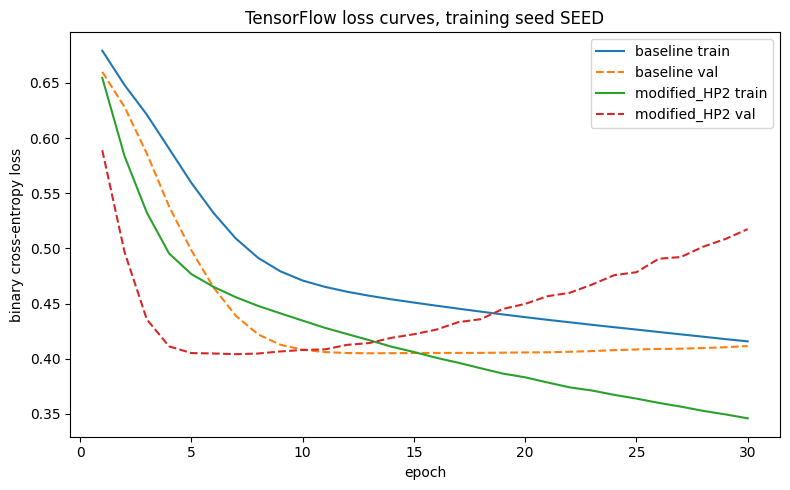

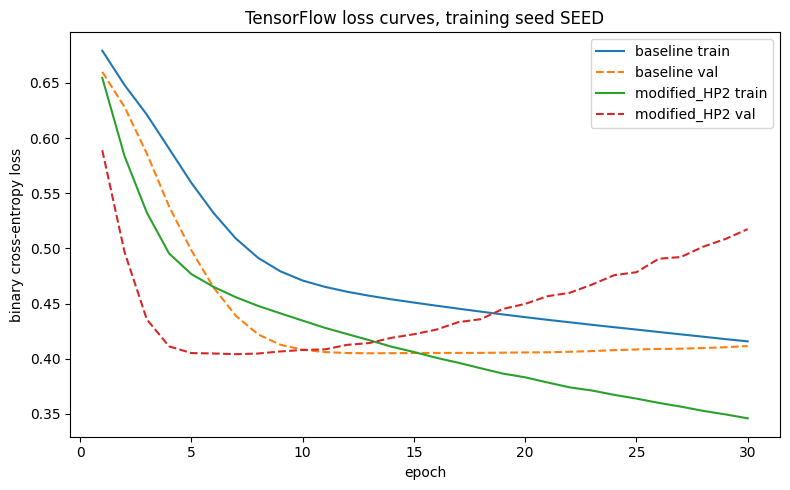

In [9]:
if TF_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name, hist in tf_histories.items():
        ax.plot(hist["epoch"], hist["train_loss"], label=f"{model_name} train")
        ax.plot(hist["epoch"], hist["val_loss"], linestyle="--", label=f"{model_name} val")
    ax.set_title("TensorFlow loss curves, training seed SEED")
    ax.set_xlabel("epoch")
    ax.set_ylabel("binary cross-entropy loss")
    ax.legend()
    plt.tight_layout()
    display(fig)
    plt.show()


## 4. Comparison and conclusion

For my assigned `HP_ID=2`, the modified model kept the same hidden layers `[64, 32]` and the same 30 epoch training length as the baseline, but increased the learning rate from `0.001` to `0.003`. In the three-seed results, the modified model had higher mean test accuracy in both frameworks: PyTorch improved from `0.7339` to `0.7602`, and TensorFlow improved from `0.7251` to `0.7573`. The modified model also had lower standard deviation across seeds in both frameworks, so it was not just one lucky run. Based on these results and the loss curves, the higher learning rate helped this dataset more than the baseline learning rate; I do not see strong evidence of overfitting from the reported validation losses.


In [10]:
summary = pd.concat([torch_summary, tf_summary], ignore_index=True)
display(summary.round(4))

if not torch_summary.empty:
    pivot = torch_summary.pivot(index="framework", columns="model", values="mean")
    torch_delta = float(pivot.loc["PyTorch", "modified_HP2"] - pivot.loc["PyTorch", "baseline"])
    print(f"PyTorch modified minus baseline mean accuracy: {torch_delta:.4f}")

if TF_AVAILABLE and not tf_summary.empty:
    pivot = tf_summary.pivot(index="framework", columns="model", values="mean")
    tf_delta = float(pivot.loc["TensorFlow", "modified_HP2"] - pivot.loc["TensorFlow", "baseline"])
    print(f"TensorFlow modified minus baseline mean accuracy: {tf_delta:.4f}")


,framework,model,mean,std
0,PyTorch,baseline,0.7339,0.0268
1,PyTorch,modified_HP2,0.7602,0.0101
2,TensorFlow,baseline,0.7251,0.0221
3,TensorFlow,modified_HP2,0.7573,0.0051


PyTorch modified minus baseline mean accuracy: 0.0263
TensorFlow modified minus baseline mean accuracy: 0.0322
